# Chapter 3: Classification

## MNIST

The MNIST dataset is widely considered the "Hello World" of Machine Learning. It contains 70,000 small images of digits handwritten by high school students and employees of the US Census Bureau. Each image is labeled with the digit it represents.

### Data Fetching and Inspection
We fetch the dataset using `fetch_openml`. A critical engineering point here is that the MNIST dataset returned by this function is already pre-split and strictly sorted into a training set (the first 60,000 images) and a test set (the last 10,000 images). 

Therefore, we do not need to apply a random split function. The training set is also pre-shuffled, ensuring that cross-validation folds will contain a balanced distribution of digits and preventing learning algorithms from being biased by sequences of similar instances.

In [5]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [6]:
X, y = mnist.data, mnist.target

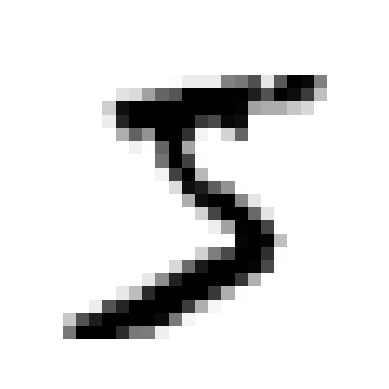

In [7]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap='binary')
    plt.axis('off')

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [8]:
y[0]

'5'

In [9]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## Training a Binary Classifier

Before tackling the full multiclass classification problem, we simplify the task to a binary classifier. We will train a model capable of distinguishing between two classes: "5" and "not-5".

We use a Stochastic Gradient Descent (SGD) classifier. This algorithm is highly efficient for large datasets because it processes training instances independently, making it perfectly suited for online learning systems.

In [11]:
# Target vectors: True for digit 5, False otherwise
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [12]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)
sgd_clf.predict([some_digit])

array([ True])

## Performance Measures
Evaluating a classifier is significantly trickier than evaluating a regressor. If we simply measure accuracy using K-fold cross-validation, the model might score over 90%. However, this is a statistical illusion. Since only about 10% of the images are 5s, a naive model that always guesses "not-5" will automatically be right 90% of the time.

To objectively evaluate the model's true capability, we must abandon simple accuracy and utilize more robust metrics: Confusion Matrix, Precision, Recall, and the F1 Score.

### Measuring Accuracy Using Cross-Validation

In [15]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

In [16]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
# Returns True if at least one prediction is True
print(any(dummy_clf.predict(X_train)))

False


In [17]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.90965, 0.90965, 0.90965])

### Confusion Matrices

The fundamental concept behind a confusion matrix is to investigate how a classifier is failing, rather than just counting the total errors. To compute this matrix, we need a set of predictions to compare against the actual targets. 

Instead of evaluating on the untouched test set (which must remain strictly locked until the final stage), we use `cross_val_predict` to generate clean out-of-fold predictions.

In [19]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]], dtype=int64)

### Precision and Recall

While the confusion matrix provides complete transparency into the model's errors, it is often more practical in engineering environments to condense this information into concise statistical metrics.

- Precision: The accuracy of the positive predictions. When the model claims an image is a 5, how often is it objectively correct?

- Recall (Sensitivity): The true positive rate. Out of all the actual 5s in the dataset, how many did the model successfully detect?

In [21]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_train_5, y_train_pred)
recall = recall_score(y_train_5, y_train_pred)

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')

Precision: 0.8371
Recall: 0.6512


The F1 score is the harmonic mean of precision and recall. Unlike a regular arithmetic mean, the harmonic mean heavily penalizes low values. This ensures that a classifier will only achieve a high F1 score if both recall and precision are high, making it an exceptionally robust and objective metric for evaluating models on highly imbalanced datasets.

In [23]:
from sklearn.metrics import f1_score

f1 = f1_score(y_train_5, y_train_pred)
print(f'F1 Score: {f1:.4f}')

F1 Score: 0.7325


### The Precision/Recall Trade-off

To deeply understand the classifier's performance, we must examine how it makes its decisions. For each instance, the `SGDClassifier` computes a score based on a decision function. If that score is greater than a specified threshold, it assigns the instance to the positive class; otherwise, it assigns it to the negative class.

A critical engineering reality is the Precision/Recall Trade-off: mathematically, increasing the threshold increases precision but reduces recall, and vice versa. 

Scikit-Learn does not let us set the threshold directly, but it does give us access to the underlying decision scores. Let's first look at the score for a single digit and see how changing the threshold affects the prediction.

In [25]:
# Access the raw decision score for a single instance
y_scores = sgd_clf.decision_function([some_digit])
print(f'Decision Score for some_digit: {y_scores:}')

# Test with a threshold of 0 (SGDClassifier's default)
threshold = 0
y_some_digit_pred = (y_scores > threshold)
print(f'Prediction with threshold 0: {y_some_digit_pred}')

Decision Score for some_digit: [2164.22030239]
Prediction with threshold 0: [ True]


In [26]:
# Test with a higher threshold
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
print(f'Prediction with threshold 3000: {y_some_digit_pred}')

Prediction with threshold 3000: [False]


This confirms that raising the threshold decreases recall: the image is actually a 5, but when the threshold is raised to 8000, the classifier misses it.

To decide which threshold to use for the entire project, we need to get the scores of all instances in the training set using `cross_val_predict`, specifying that we want decision scores instead of binary predictions.

In [28]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method='decision_function')

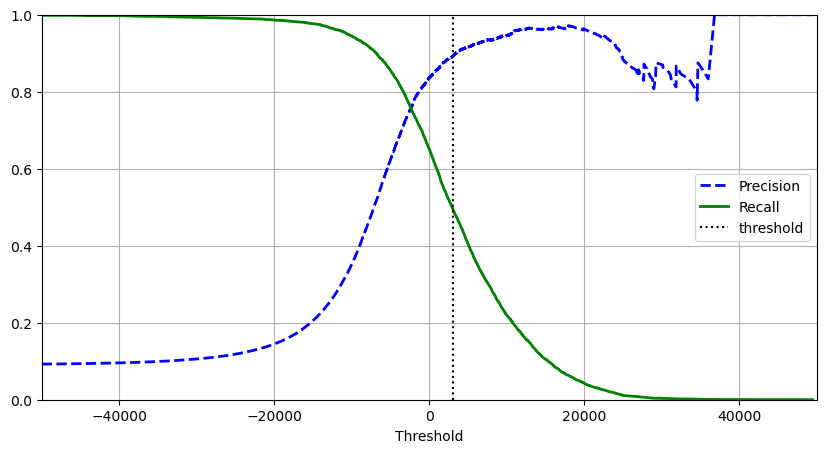

In [30]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall', linewidth=2)
plt.vlines(threshold, 0, 1.0, 'k', 'dotted', label='threshold')
plt.xlabel('Threshold')
plt.legend(loc='center right')
plt.grid()
plt.axis([-50000, 50000, 0, 1])
plt.show()

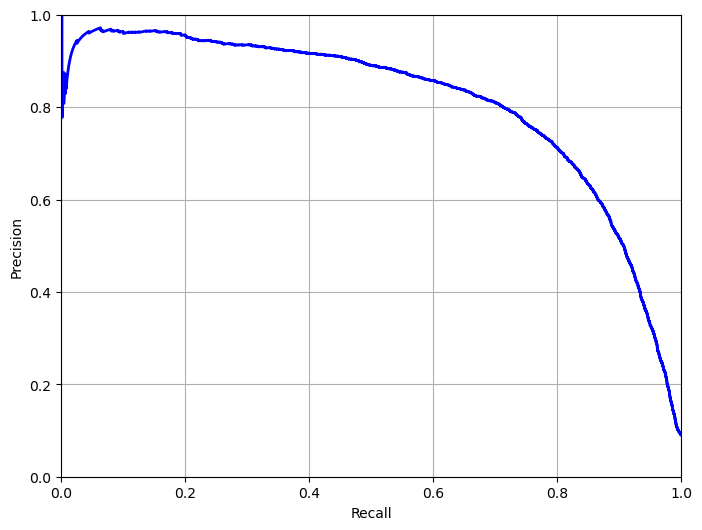

In [34]:
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, 'b-', linewidth=2, label='Precision/Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.show()

Suppose the business requires exactly 90% precision. Instead of guessing, we can mathematically search for the lowest threshold that gives us at least 90% precision using `np.argmax`.

In [43]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
print(f'The threshold required to reach 90% precision is {threshold_for_90_precision:.4f}')

The threshold required to reach 90% precision is 3370.0195


In [53]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)
precision_at_90 = precision_score(y_train_5, y_train_pred_90)
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)

print(f'Precision at this threshold is {precision_at_90:.4f}')
print(f'Recall at this threshold is {recall_at_90_precision:.4f}')

Precision at this threshold is 0.9000
Recall at this threshold is 0.4800
